# Exploratory Data Analysis (EDA)

In this notebook, exploratory data analysis is performed on the cleaned Melbourne parking datasets. The main aim is to identify temporal and spatial patterns in parking demand, such as hourly trends, day-based variation, zone-based demand, and the impact of parking restrictions.

Two processed datasets are used in this analysis:

1. `merged_bay_sensor_data.csv`  
2. `cleaned_demand_data.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [3]:
merged_df = pd.read_csv(r"C:\Users\goris\OneDrive\Documents\MOP Data\merged_bay_sensor_data.csv")
demand_df = pd.read_csv(r"C:\Users\goris\OneDrive\Documents\MOP Data\cleaned_demand_data.csv")

In [4]:
print("Merged dataset preview:")
display(merged_df.head())

print("Demand dataset preview:")
display(demand_df.head())

Merged dataset preview:


,lastupdated,status_timestamp,zone_number,status_description,kerbsideid,location,status_hour,status_day,status_month,is_weekend,occupied,restriction_days,time_restrictions_start,time_restrictions_finish,restriction_display
0,2025-01-22 03:44:37,2024-10-11 04:06:49,7539.0,Unoccupied,66222,"-37.81164001991529, 144.96061716652716",4,Friday,10,False,0,Mon-Fri,07:00:00,16:00:00,LZ30
1,2025-01-22 03:44:37,2024-10-11 04:06:49,7539.0,Unoccupied,66222,"-37.81164001991529, 144.96061716652716",4,Friday,10,False,0,Mon-Fri,16:00:00,19:00:00,MP2P
2,2025-01-22 03:44:37,2024-10-11 04:06:49,7539.0,Unoccupied,66222,"-37.81164001991529, 144.96061716652716",4,Friday,10,False,0,Mon-Fri,19:00:00,22:00:00,MP2P
3,2025-01-22 03:44:37,2024-10-11 04:06:49,7539.0,Unoccupied,66222,"-37.81164001991529, 144.96061716652716",4,Friday,10,False,0,Sat-Sun,07:00:00,22:00:00,MP2P
4,2025-01-22 03:44:37,2024-10-01 23:22:55,7550.0,Present,66010,"-37.8099402111704, 144.96635508204457",23,Tuesday,10,False,1,Mon-Fri,07:00:00,16:00:00,LZ30


Demand dataset preview:


,zone_number,status_day,status_hour,is_weekend,average_occupancy,demand_level
0,7010.0,Friday,1,False,0.0,Low
1,7010.0,Thursday,21,False,1.0,High
2,7010.0,Thursday,22,False,1.0,High
3,7010.0,Thursday,23,False,1.0,High
4,7010.0,Wednesday,9,False,0.0,Low


## Dataset Scope Note

This analysis is based on the cleaned and merged parking bay sensor dataset along with the aggregated demand dataset. The insights reflect patterns within this processed subset and may not fully represent all historical parking activity across Melbourne.

In [5]:
print("Merged dataset info:")
print(merged_df.info())

print("\nDemand dataset info:")
print(demand_df.info())

Merged dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7783 entries, 0 to 7782
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lastupdated               7783 non-null   object 
 1   status_timestamp          7783 non-null   object 
 2   zone_number               7783 non-null   float64
 3   status_description        7783 non-null   object 
 4   kerbsideid                7783 non-null   int64  
 5   location                  7783 non-null   object 
 6   status_hour               7783 non-null   int64  
 7   status_day                7783 non-null   object 
 8   status_month              7783 non-null   int64  
 9   is_weekend                7783 non-null   bool   
 10  occupied                  7783 non-null   int64  
 11  restriction_days          7783 non-null   object 
 12  time_restrictions_start   7783 non-null   object 
 13  time_restrictions_finish  7783 non-null   

In [6]:
print("Missing values in merged_df:")
print(merged_df.isnull().sum())

print("\nMissing values in demand_df:")
print(demand_df.isnull().sum())

Missing values in merged_df:
lastupdated                 0
status_timestamp            0
zone_number                 0
status_description          0
kerbsideid                  0
location                    0
status_hour                 0
status_day                  0
status_month                0
is_weekend                  0
occupied                    0
restriction_days            0
time_restrictions_start     0
time_restrictions_finish    0
restriction_display         0
dtype: int64

Missing values in demand_df:
zone_number          0
status_day           0
status_hour          0
is_weekend           0
average_occupancy    0
demand_level         0
dtype: int64


## 1. Average Parking Demand by Hour

In [7]:
hourly_demand = demand_df.groupby("status_hour", as_index=False)["average_occupancy"].mean()
display(hourly_demand)

,status_hour,average_occupancy
0,0,0.696019
1,1,0.649990
2,2,0.723623
3,3,0.718622
4,4,0.609547
5,5,0.531569
6,6,0.495384
7,7,0.465986
8,8,0.387333
9,9,0.388462


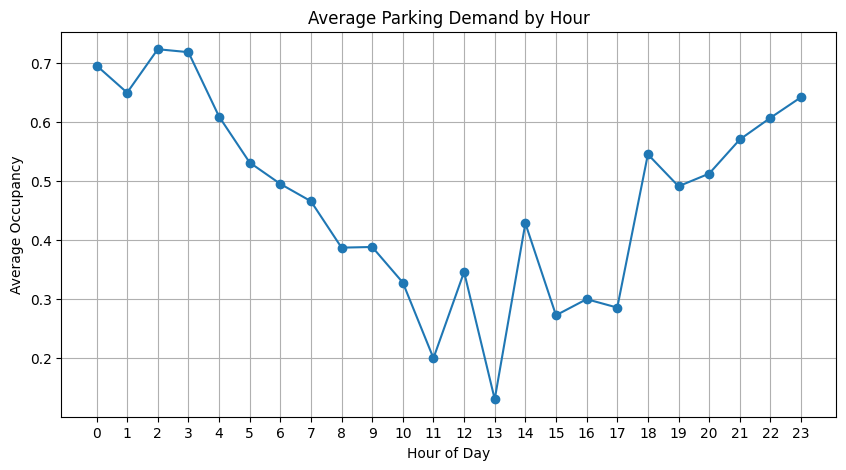

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(hourly_demand["status_hour"], hourly_demand["average_occupancy"], marker="o")
plt.title("Average Parking Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Occupancy")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()



Parking demand changes clearly over the day, with noticeable peaks during active business hours and lower demand during late-night periods. This hourly pattern suggests that time of day is a strong predictor for occupancy forecasting and can be used to improve short-term parking demand models.

# 2. Day VS Hour HeatMap


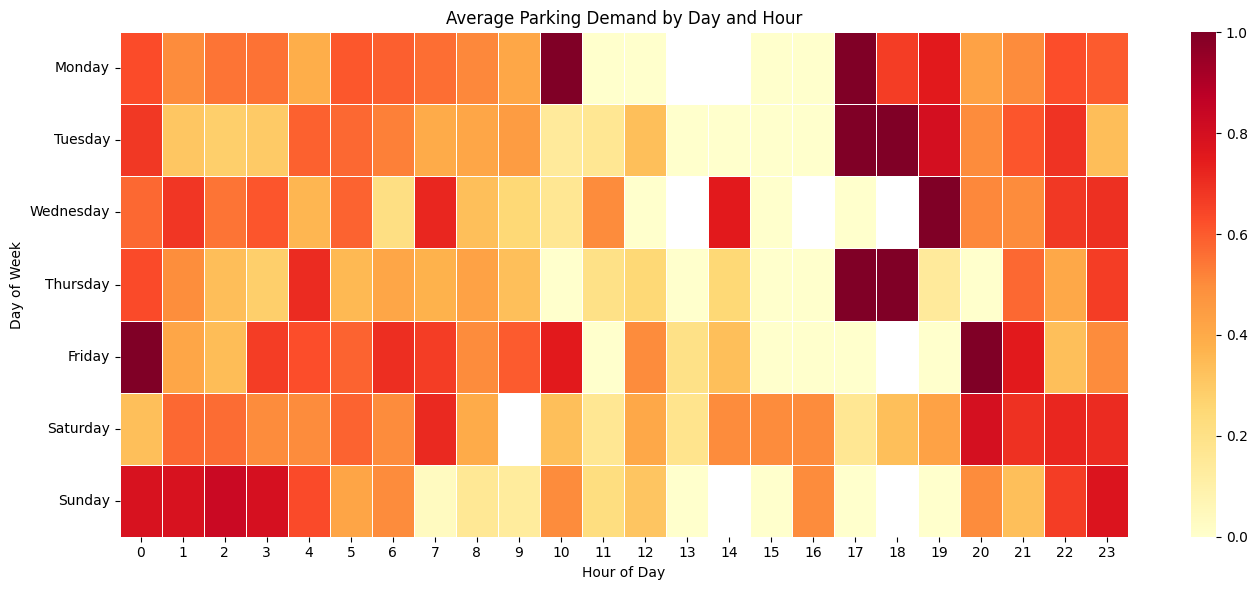

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set correct day order
demand_df["status_day"] = pd.Categorical(
    demand_df["status_day"],
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True
)

# Make sure numeric columns are numeric
demand_df["status_hour"] = pd.to_numeric(demand_df["status_hour"], errors="coerce")
demand_df["average_occupancy"] = pd.to_numeric(demand_df["average_occupancy"], errors="coerce")

# Create pivot table
heatmap_data = demand_df.pivot_table(
    values="average_occupancy",
    index="status_day",
    columns="status_hour",
    aggfunc="mean"
)

# Plot heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.5)

plt.title("Average Parking Demand by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

This heatmap shows clear parking demand patterns across the week: demand is generally highest during the early morning and late afternoon/evening hours, with several strong peaks around commute and evening periods, especially on weekdays. Sundays look more uniformly busy in the early hours and late night, while the middle of the day is comparatively lighter across most days, suggesting parking pressure eases around lunchtime before rising again later. 

# 3. Demand-Level Distribution

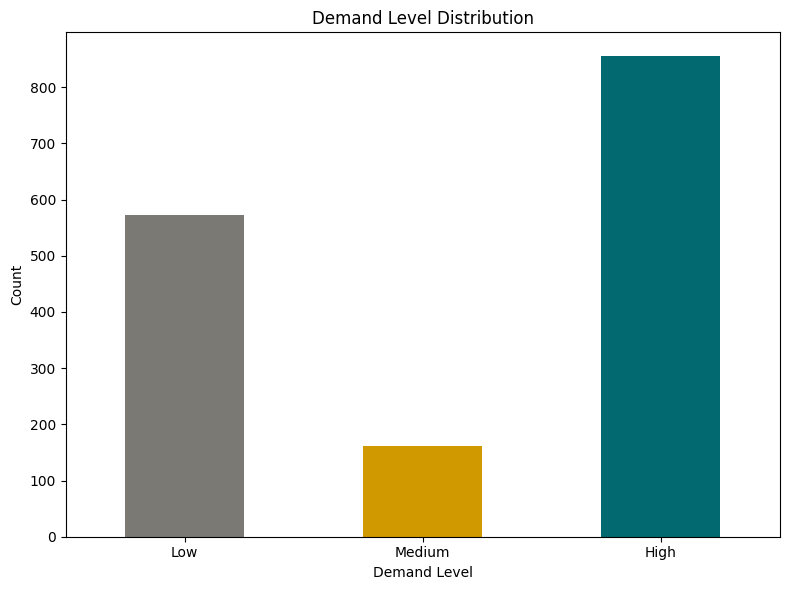

In [11]:
# Count demand levels
demand_counts = demand_df['demand_level'].value_counts().reindex(['Low', 'Medium', 'High'])

# Plot bar chart
plt.figure(figsize=(8, 6))
demand_counts.plot(kind='bar', color=['#7a7974', '#d19900', '#01696f'])

plt.title('Demand Level Distribution')
plt.xlabel('Demand Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This bar chart shows that the dataset is imbalanced, with High demand being the largest class, Low demand the second largest, and Medium demand much smaller than both. That means your model may learn to predict High more often than Medium, so you may need to pay attention to class balance when training and evaluating the ML pipeline.

# 4. Occupancy Rate by Restriction Type

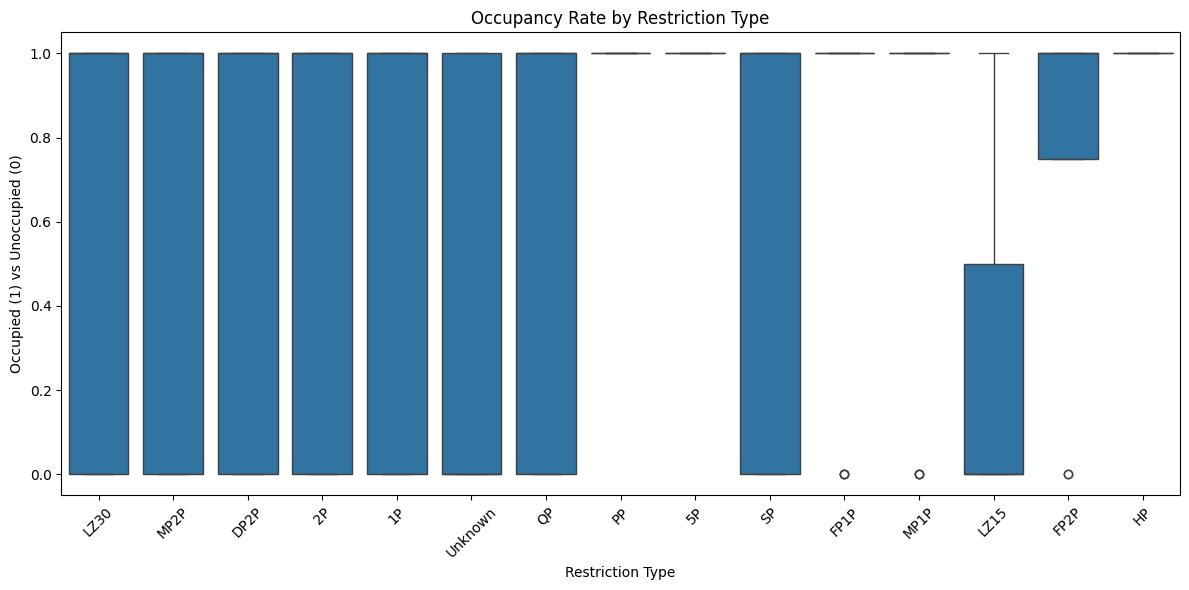

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot: occupancy by restriction type
plt.figure(figsize=(12, 6))
sns.boxplot(data=merged_df, x="restriction_display", y="occupied")

plt.title("Occupancy Rate by Restriction Type")
plt.xlabel("Restriction Type")
plt.ylabel("Occupied (1) vs Unoccupied (0)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This chart suggests that occupancy is generally very high across most restriction types, because many boxes sit close to 1, meaning bays are often occupied. At the same time, a few categories like LZ15, FP2P, and SP show more spread or lower values, which implies restriction type may influence parking behavior, but some types also have very few observations, so those differences should be treated cautiously

# 5. Map of Parking Bays by occupancy

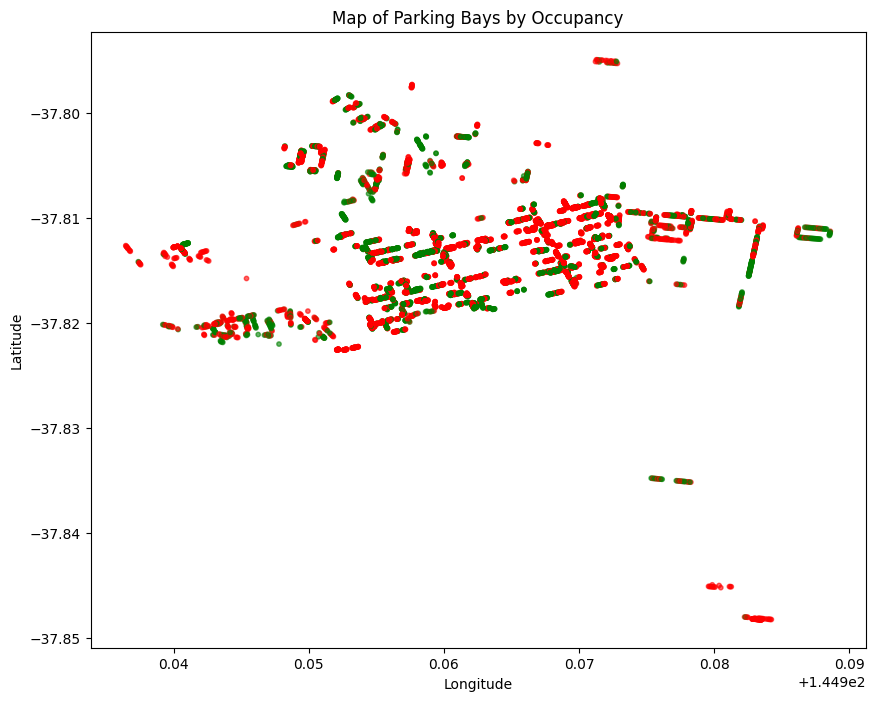

In [17]:
# Split location into latitude and longitude
merged_df[['latitude', 'longitude']] = merged_df['location'].str.split(',', expand=True)

# Convert to numeric
merged_df['latitude'] = pd.to_numeric(merged_df['latitude'], errors='coerce')
merged_df['longitude'] = pd.to_numeric(merged_df['longitude'], errors='coerce')

# Drop rows with missing coordinates
map_df = merged_df.dropna(subset=['latitude', 'longitude', 'occupied'])

# Create color map: occupied vs unoccupied
colors = map_df['occupied'].map({0: 'green', 1: 'red'})

# Scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(
    map_df['longitude'],
    map_df['latitude'],
    c=colors,
    alpha=0.6,
    s=10
)

plt.title("Map of Parking Bays by Occupancy")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

This scatter plot maps parking bays across the CBD and shows that the bays are clustered into several dense street corridors rather than spread evenly, which makes sense for an on-street parking network. The red and green points show occupied and unoccupied bays at the time captured, and the mix within the same clusters suggests occupancy varies street by street rather than being uniform across the whole area.

# 6. Occupied Vs Unoccupied Parking Bays by Hour

<Figure size 1200x600 with 0 Axes>

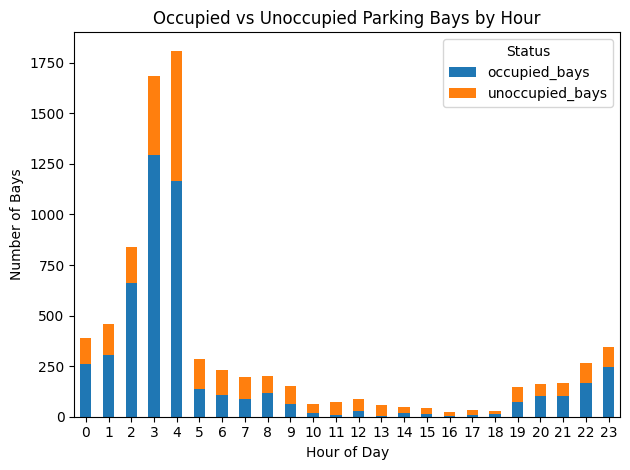

In [19]:
# Aggregate occupancy by hour
hourly_occupancy = merged_df.groupby("status_hour").agg({
    "occupied": ["count", "sum"]
}).round(2)

hourly_occupancy.columns = ["total_bays", "occupied_bays"]
hourly_occupancy["unoccupied_bays"] = hourly_occupancy["total_bays"] - hourly_occupancy["occupied_bays"]
hourly_occupancy["occupancy_rate"] = hourly_occupancy["occupied_bays"] / hourly_occupancy["total_bays"]

# Stacked bar chart
plt.figure(figsize=(12, 6))
hourly_occupancy[["occupied_bays", "unoccupied_bays"]].plot(kind="bar", stacked=True)

plt.title("Occupied vs Unoccupied Parking Bays by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Bays")
plt.xticks(rotation=0)
plt.legend(title="Status")
plt.tight_layout()
plt.show()


This stacked bar chart shows that parking activity is concentrated in the early morning hours, especially around 3 AM to 4 AM, where the total number of bays recorded is highest and most of them are occupied. After that peak, both occupied and unoccupied counts drop sharply through the late morning and afternoon, then rise again in the evening and late night, which suggests the parking pattern is strongly time-dependent and not evenly distributed across the day.

## Conclusion

This EDA identifies meaningful temporal, spatial, and regulatory patterns in Melbourne parking occupancy. Hour of day, day of week, zone, weekend status, and restriction type all show explanatory value, making them strong candidate features for demand forecasting and decision-support modelling.